## **Aplicação de MLP para Regressão: Concrete Compressive Strength Dataset**

Vamos utilizar *Multilayer Perceptron (MLP)* para tarefa de regressão no [**Concrete Compressive Strength Dataset**](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength).

In [32]:
!pip install ucimlrepo

### **Pré-processamento dos dados**

#### **Dataset**

In [33]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=165)
X, y = dataset.data.features, dataset.data.targets

In [34]:
print(X)

      Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0      540.0                 0.0      0.0  162.0               2.5   
1      540.0                 0.0      0.0  162.0               2.5   
2      332.5               142.5      0.0  228.0               0.0   
3      332.5               142.5      0.0  228.0               0.0   
4      198.6               132.4      0.0  192.0               0.0   
...      ...                 ...      ...    ...               ...   
1025   276.4               116.0     90.3  179.6               8.9   
1026   322.2                 0.0    115.6  196.0              10.4   
1027   148.5               139.4    108.6  192.7               6.1   
1028   159.1               186.7      0.0  175.6              11.3   
1029   260.9               100.5     78.3  200.6               8.6   

      Coarse Aggregate  Fine Aggregate  Age  
0               1040.0           676.0   28  
1               1055.0           676.0   28  
2                932.

In [35]:
print(y)

      Concrete compressive strength
0                             79.99
1                             61.89
2                             40.27
3                             41.05
4                             44.30
...                             ...
1025                          44.28
1026                          31.18
1027                          23.70
1028                          32.77
1029                          32.40

[1030 rows x 1 columns]


#### **Dados de Treino e Dados de Teste**

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### **Padronização dos dados**

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#### **Classe Dataset customizada**

In [38]:
import torch
import torch.nn as nn

In [39]:
from torch.utils.data import Dataset, DataLoader

class ConcreteDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y.values, dtype=torch.float32)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

train_dataset = ConcreteDataset(X_train, y_train)
test_dataset  = ConcreteDataset(X_test,  y_test)

#### **DataLoaders**

In [40]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size
)

for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([32, 8])
torch.Size([32, 1])


### **Implementação do Modelo**

In [41]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

class ConcreteNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
      nn.Linear(8, 64),
      nn.ReLU(),
      nn.Linear(64, 32),
      nn.ReLU(),
      nn.Linear(32, 16),
      nn.ReLU(),
      nn.Linear(16, 1)
    )

  def forward(self, x):
    return self.network(x)

model = ConcreteNet().to(device)
print(model)

ConcreteNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


O modelo foi definido com a seguinte sequência de camadas:

$$
\text{model} = \text{Sequential}\bigl(
    \underbrace{\text{Linear}(8,64)}_{\mathbf{W}^{(1)} \in \mathbb{R}^{64\times8},\; \mathbf{b}^{(1)} \in \mathbb{R}^{64}},\;
    \operatorname{ReLU},\;
    \underbrace{\text{Linear}(64,32)}_{\mathbf{W}^{(2)} \in \mathbb{R}^{32\times64},\; \mathbf{b}^{(2)} \in \mathbb{R}^{32}},\;
    \operatorname{ReLU},\;
    \underbrace{\text{Linear}(32,16)}_{\mathbf{W}^{(3)} \in \mathbb{R}^{16\times32},\; \mathbf{b}^{(3)} \in \mathbb{R}^{3}}\;
    \operatorname{ReLU},\;
    \underbrace{\text{Linear}(16,1)}_{\mathbf{W}^{(3)} \in \mathbb{R}^{1\times16},\; \mathbf{b}^{(3)} \in \mathbb{R}^{1}}\;
\bigr)
$$

Cada camada $\text{Linear}$ computa:

$$
\mathbf{a}^{(\ell)} = \mathbf{W}^{(\ell)}\mathbf{z}^{(\ell-1)} + \mathbf{b}^{(\ell)}
$$

e a função de ativação é aplicada elemento a elemento:

$$
\mathbf{z}^{(\ell)} = \sigma\!\left(\mathbf{a}^{(\ell)}\right)
$$

### **Função de Treino para 1 Epoch**

In [42]:
def train(dataloader, model, loss_fn, optimizer):
  model.train()
  total_loss = 0

  for X, y in dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    total_loss += loss.item()

  return total_loss / len(dataloader)

### **Função de Teste**

In [43]:
def test(loader, model, loss_fn):
  model.eval()
  total_loss = 0

  with torch.no_grad():
    for X, y in loader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      total_loss += loss_fn(pred, y).item()

  n = len(loader.dataset)
  loss = total_loss/len(loader)

  return loss

## **Treinamento do Modelo**

#### **Definindo a função de perda e o otimizador**

In [44]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-3
)

#### **Loop de Epochs**

In [45]:
epochs = 100
train_losses = []
test_losses  = []

for t in range(epochs):
    train_loss = train(train_loader, model, loss_fn, optimizer)
    test_loss  = test(test_loader, model, loss_fn)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (t + 1) % 10 == 0:
        print(f"Epoch {t+1:3d}/{epochs} | train: {train_loss:.4f} | test: {test_loss:.4f}")

print("\nDone!")

Epoch  10/100 | train: 169.5556 | test: 151.4029
Epoch  20/100 | train: 129.1230 | test: 120.5506
Epoch  30/100 | train: 94.2521 | test: 92.5737
Epoch  40/100 | train: 60.8679 | test: 68.2353
Epoch  50/100 | train: 43.4170 | test: 48.5614
Epoch  60/100 | train: 36.8201 | test: 42.3172
Epoch  70/100 | train: 32.9344 | test: 40.6130
Epoch  80/100 | train: 31.0302 | test: 36.7629
Epoch  90/100 | train: 27.7342 | test: 35.6026
Epoch 100/100 | train: 26.1154 | test: 36.4120

Done!


#### **Curva de Loss**

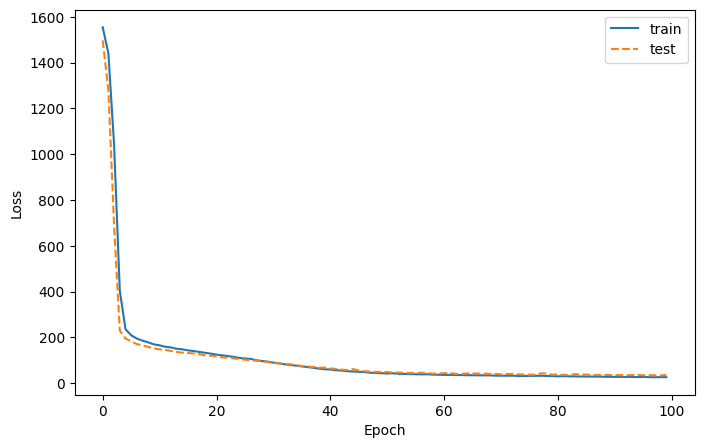

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="train")
plt.plot(test_losses,  label="test", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### **Mátricas do Modelo**

In [47]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

def regression_report(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {np.sqrt(mse):.4f}")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"R²:   {r2_score(y_true, y_pred):.4f}")

In [48]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X).cpu()
        y_pred.append(pred)
        y_true.append(y)

y_true = torch.cat(y_true).numpy()
y_pred  = torch.cat(y_pred).numpy()

regression_report(y_true, y_pred)

MSE:  36.9505
RMSE: 6.0787
MAE:  4.6587
R²:   0.8566
